# Coupling matrices with marginal strips

This notebook generates `fig:kantorovich-coupling-matrix-marginals`. A discrete coupling
$$
P\in U(a,b)=\{P\geq 0:\;P\mathbf 1=a,\;P^\top\mathbf 1=b\}
$$
can be read directly as an image once the source and target bins are ordered. The panels compare the independent product plan $a\otimes b$ with the one-dimensional optimal plan for a coarse and a dense discretization. The side strips are tightly attached to the boxed coupling and show the prescribed marginals; only the dense optimal panel overlays the red barycentric projection of each source bin.


In [1]:

from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from math import comb

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    figure_dir,
    box_axes,
    coupling_box,
    remove_axes,
    save_pdf,
    setup_matplotlib,
    interp_color,
)

setup_matplotlib()

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def mixture_pdf(x, weights, means, stds):
    out = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        out += w * normal_pdf(x, m, s)
    return out


def normalize_weights(w):
    w = np.asarray(w, dtype=float)
    w = np.maximum(w, 1e-15)
    return w / w.sum()


def histogram_on_grid(n, weights, means, stds, xmin=-3.0, xmax=3.0):
    x = np.linspace(xmin, xmax, n)
    w = normalize_weights(mixture_pdf(x, weights, means, stds))
    return x, w


def monotone_plan(a, b):
    a = np.asarray(a, dtype=float).copy()
    b = np.asarray(b, dtype=float).copy()
    n, m = len(a), len(b)
    P = np.zeros((n, m), dtype=float)
    i = j = 0
    while i < n and j < m:
        mass = min(a[i], b[j])
        P[i, j] = mass
        a[i] -= mass
        b[j] -= mass
        if a[i] <= 1e-14:
            i += 1
        if j < m and b[j] <= 1e-14:
            j += 1
    return P


def barycentric_curve(P):
    row = P.sum(axis=1)
    cols = np.arange(P.shape[1], dtype=float)
    return (P @ cols) / np.maximum(row, 1e-15)


def draw_matrix_with_marginals(P, a, b, path, *, row_color=RED, col_color=BLUE, curve_color=RED, gamma=0.58, show_curve=False):
    n, m = P.shape
    fig, ax = plt.subplots(figsize=(2.35, 2.35))
    image = P / max(P.max(), 1e-15)
    ax.imshow(image ** gamma, cmap='Greys', origin='lower', extent=(-0.5, m - 0.5, -0.5, n - 0.5), interpolation='nearest', vmin=0, vmax=1, aspect='auto')

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_frame_on(False)
    coupling_box(ax, n, m, linewidth=0.62)

    ax.set_xlim(-0.5 - 0.18 * m, m - 0.5)
    ax.set_ylim(-0.5, n - 0.5 + 0.18 * n)
    ax.set_xticks([])
    ax.set_yticks([])

    # Attached marginal strips.  They live just outside the matrix square.
    yy = np.arange(n)
    xx = np.arange(m)
    left_base = -0.5 - 0.018 * m
    left_scale = 0.13 * m / max(a.max(), 1e-15)
    ax.fill_betweenx(yy, left_base, left_base - left_scale * a, color=row_color, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(left_base - left_scale * a, yy, color=row_color, lw=0.95, zorder=4)

    top_base = n - 0.5 + 0.018 * n
    top_scale = 0.13 * n / max(b.max(), 1e-15)
    ax.fill_between(xx, top_base, top_base + top_scale * b, color=col_color, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(xx, top_base + top_scale * b, color=col_color, lw=0.95, zorder=4)

    if show_curve:
        # Barycentric projection i -> sum_j P_ij j / a_i.
        jbar = barycentric_curve(P)
        rows = np.arange(n)
        ax.plot(jbar, rows, color=curve_color, lw=0.95, alpha=0.92, zorder=5)
    save_pdf(fig, path, pad_inches=0.04)
    plt.close(fig)

fig_name = "kantorovich-coupling-matrix-marginals"
out = figure_dir(fig_name)


## Gaussian-mixture marginals

The two measures have shifted modes, different widths, and different amplitudes.  In one dimension, the optimal plan is computed by the monotone north-west sweep, which is exact for convex transport costs and avoids any heavy linear programming.

In [2]:
alpha_params = dict(weights=[0.50, 0.35, 0.15], means=[-1.55, -0.20, 1.08], stds=[0.26, 0.42, 0.22])
beta_params = dict(weights=[0.22, 0.50, 0.28], means=[-1.03, 0.72, 1.82], stds=[0.21, 0.36, 0.30])

for n, tag in [(20, '20'), (200, '200')]:
    _, a = histogram_on_grid(n, **alpha_params)
    _, b = histogram_on_grid(n, **beta_params)
    P_prod = np.outer(a, b)
    P_ot = monotone_plan(a, b)
    draw_matrix_with_marginals(P_prod, a, b, out / f'product-{tag}.pdf', gamma=0.55, show_curve=False)
    draw_matrix_with_marginals(P_ot, a, b, out / f'optimal-{tag}.pdf', gamma=0.36, show_curve=(tag == '200'))


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


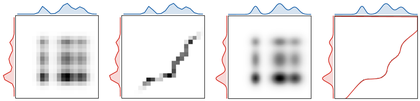

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/kantorovich-coupling-matrix-marginals.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/kantorovich-coupling-matrix-marginals.png")
display(Image(filename=str(_thumb)))
